In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
!pip install catboost

# Models
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Handling imbalance
from imblearn.over_sampling import SMOTE


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv("/content/diabetes.csv")

In [ ]:

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].mean(), inplace=True)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle imbalance
smote = SMOTE()
X_res, y_res = smote.fit_resample(X_scaled, y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# ==========================================
# 4. Models
# ==========================================
models = {
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100)
}

# ==========================================
# 5. Evaluation Function
# ==========================================
def evaluate_model(name, model):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

# ==========================================
# 6. Evaluate ML Models
# ==========================================
results = []

for name, model in models.items():
    results.append(evaluate_model(name, model))

# ==========================================
# 7. ANN Model
# ==========================================
ann = Sequential()
ann.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, batch_size=10, verbose=0)

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)
y_prob_ann = ann.predict(X_test)

results.append({
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, y_pred_ann),
    "Precision": precision_score(y_test, y_pred_ann),
    "Recall": recall_score(y_test, y_pred_ann),
    "F1": f1_score(y_test, y_pred_ann),
    "ROC_AUC": roc_auc_score(y_test, y_prob_ann)
})



/tmp/ipykernel_3058/2558733145.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 399, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1145
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498750 -> initscore=-0.005000
[LightGBM] [Info] Start training from score -0.005000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].mean(), inplace=True)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# ==========================================
# 4. Feature Scaling
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 5. Handle Class Imbalance
# ==========================================
smote = SMOTE()
X_res, y_res = smote.fit_resample(X_scaled, y)

# ==========================================
# 6. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# ==========================================
# 7. Initialize Models
# ==========================================
models = {
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100)
}

# ==========================================
# 8. Evaluation Function (Full Metrics)
# ==========================================
def evaluate_model_full(name, model):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred)*100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred)*100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred)*100, 2),
        "F1 Score (%)": round(f1_score(y_test, y_pred)*100, 2),
        "ROC-AUC (%)": round(roc_auc_score(y_test, y_prob)*100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


/tmp/ipykernel_3058/677523930.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
def evaluate_model_full(name, model):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred)*100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred)*100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred)*100, 2),
        "F1 Score (%)": round(f1_score(y_test, y_pred)*100, 2),
        "ROC-AUC (%)": round(roc_auc_score(y_test, y_prob)*100, 2),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }

In [ ]:
from sklearn.metrics import confusion_matrix
ann = Sequential()
ann.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, batch_size=10, verbose=0)

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)
y_prob_ann = ann.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ann).ravel()

results.append({
    "Model": "ANN",
    "Accuracy (%)": round(accuracy_score(y_test, y_pred_ann)*100, 2),
    "Precision (%)": round(precision_score(y_test, y_pred_ann)*100, 2),
    "Recall (%)": round(recall_score(y_test, y_pred_ann)*100, 2),
    "F1 Score (%)": round(f1_score(y_test, y_pred_ann)*100, 2),
    "ROC-AUC (%)": round(roc_auc_score(y_test, y_prob_ann)*100, 2),
    "TP": tp,
    "TN": tn,
    "FP": fp,
    "FN": fn
})

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
df_results = pd.DataFrame(results)

# Check available columns
print("Available Columns:", df_results.columns)

# Remove extra spaces from column names
df_results.columns = df_results.columns.str.strip()

# Sort only if F1 Score column exists
if "F1 Score (%)" in df_results.columns:
    df_results = df_results.sort_values(by="F1 Score (%)", ascending=False)

elif "F1 Score" in df_results.columns:
    df_results = df_results.sort_values(by="F1 Score", ascending=False)

else:
    print("⚠️ F1 Score column not found. Showing unsorted table.")

print("\n📊 COMPLETE PERFORMANCE METRICS TABLE:\n")
print(df_results)

Available Columns: Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC',
       'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)',
       'ROC-AUC (%)', 'TP', 'TN', 'FP', 'FN'],
      dtype='object')

📊 COMPLETE PERFORMANCE METRICS TABLE:

         Model  Accuracy  Precision    Recall        F1   ROC_AUC  \
4          ANN       NaN        NaN       NaN       NaN       NaN   
0     LightGBM     0.765   0.745455  0.811881  0.777251  0.850985   
1     CatBoost     0.805   0.776786  0.861386  0.816901  0.861186   
2  Extra Trees     0.820   0.792793  0.871287  0.830189  0.896840   
3          ANN     0.770   0.739130  0.841584  0.787037  0.844784   

   Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  ROC-AUC (%)    TP  \
4          77.0          75.23       81.19          78.1        83.16  82.0   
0           NaN            NaN         NaN           NaN          NaN   NaN   
1           NaN            NaN         NaN           NaN          NaN   NaN   
2  

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# ==========================================
# 2. Evaluation Function (All Metrics)
# ==========================================
def evaluate_model_full(name, model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities (needed for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.predict(X_test)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return {
        "Model": name,
        "Accuracy (%)": round(accuracy*100, 2),
        "Precision (%)": round(precision*100, 2),
        "Recall (%)": round(recall*100, 2),
        "F1 Score (%)": round(f1*100, 2),
        "ROC-AUC (%)": round(roc_auc*100, 2),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

# ==========================================
# 3. Evaluate All ML Models
# ==========================================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    results.append(evaluate_model_full(name, model, X_test, y_test))

# ==========================================
# 4. ANN Evaluation (Handled Separately)
# ==========================================
y_prob_ann = ann.predict(X_test).flatten()
y_pred_ann = (y_prob_ann > 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ann).ravel()

results.append({
    "Model": "ANN",
    "Accuracy (%)": round(accuracy_score(y_test, y_pred_ann)*100, 2),
    "Precision (%)": round(precision_score(y_test, y_pred_ann)*100, 2),
    "Recall (%)": round(recall_score(y_test, y_pred_ann)*100, 2),
    "F1 Score (%)": round(f1_score(y_test, y_pred_ann)*100, 2),
    "ROC-AUC (%)": round(roc_auc_score(y_test, y_prob_ann)*100, 2),
    "TP": tp,
    "TN": tn,
    "FP": fp,
    "FN": fn
})

# ==========================================
# 5. Final Results Table
# ==========================================
df_results = pd.DataFrame(results)

# Sort by F1 Score (optional)
df_results = df_results.sort_values(by="F1 Score (%)", ascending=False)

print("\n📊 COMPLETE PERFORMANCE METRICS TABLE:\n")
print(df_results)

[LightGBM] [Info] Number of positive: 399, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1142
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498750 -> initscore=-0.005000
[LightGBM] [Info] Start training from score -0.005000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

📊 COMPLETE PERFORMANCE METRICS TABLE:

         Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  \
2  Extra Trees          84.0          79.49       92.08         85.32   
1     CatBoost          80.0          76.52       87.13         81.48   
0     LightGBM          79.0          76.58       84.16         80.19   
3          ANN          77.0          75.23       81.19         78.10   

   ROC-AUC (%)  TP  TN  FP  FN  
2        91.18  93  75  24   8  
1        85.02  88  72  27  13  
0        85.78  85  73  26  16  
3        83.16  82  72  27  19  


In [ ]:
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_res, y_res, cv=5, scoring='f1')
    cv_scores[name] = scores
    print(f"{name} Mean F1 Score: {scores.mean():.4f}")




[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1257
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Mean F1 Score: 0.8248


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CatBoost Mean F1 Score: 0.8190
Extra Trees Mean F1 Score: 0.8559


In [ ]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    cv_scores["Extra Trees"],
    cv_scores["CatBoost"],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.0922577148673578
P-value: 0.3065324901114055


In [ ]:
df_results["Score"] = (
    0.35 * (df_results["Recall (%)"]/100) +
    0.30 * (df_results["F1 Score (%)"]/100) +
    0.20 * (df_results["ROC-AUC (%)"]/100) +
    0.10 * (df_results["Precision (%)"]/100) +
    0.05 * (df_results["Accuracy (%)"]/100)
)

df_results = df_results.sort_values(by="Score", ascending=False)

print("\n🏆 Model Ranking:\n")
print(df_results)

# ==========================================
# 15. Best Model Selection
# ==========================================
best_model = df_results.iloc[0]["Model"]
print(f"\n✅ Best Model: {best_model}")


🏆 Model Ranking:

         Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  \
2  Extra Trees          84.0          79.49       92.08         85.32   
1     CatBoost          80.0          76.52       87.13         81.48   
0     LightGBM          79.0          76.58       84.16         80.19   
3          ANN          77.0          75.23       81.19         78.10   

   ROC-AUC (%)  TP  TN  FP  FN     Score  
2        91.18  93  75  24   8  0.882090  
1        85.02  88  72  27  13  0.835955  
0        85.78  85  73  26  16  0.822770  
3        83.16  82  72  27  19  0.798515  

✅ Best Model: Extra Trees


In [ ]:
if p_value < 0.05:
    print("✔ The best model is statistically superior.")
else:
    print("⚠️ No statistically significant difference between top models.")

⚠️ No statistically significant difference between top models.


In [ ]:
!pip install shap



In [ ]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model   # store trained model

[LightGBM] [Info] Number of positive: 399, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1142
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498750 -> initscore=-0.005000
[LightGBM] [Info] Start training from score -0.005000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
best_model_name = df_results.iloc[0]["Model"]

best_model = trained_models[best_model_name]   # ✅ actual model

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreesClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning

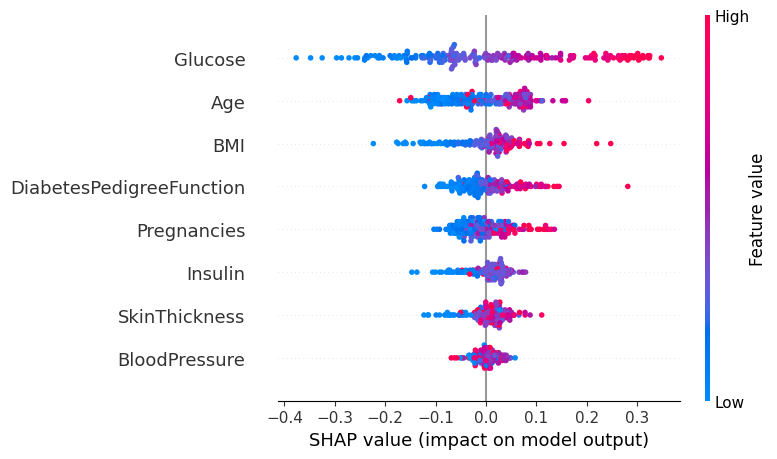

In [ ]:
import shap

explainer = shap.Explainer(best_model.predict_proba, X_train_df)

shap_values = explainer(X_test_df)

shap.summary_plot(shap_values[:, :, 1], X_test_df)

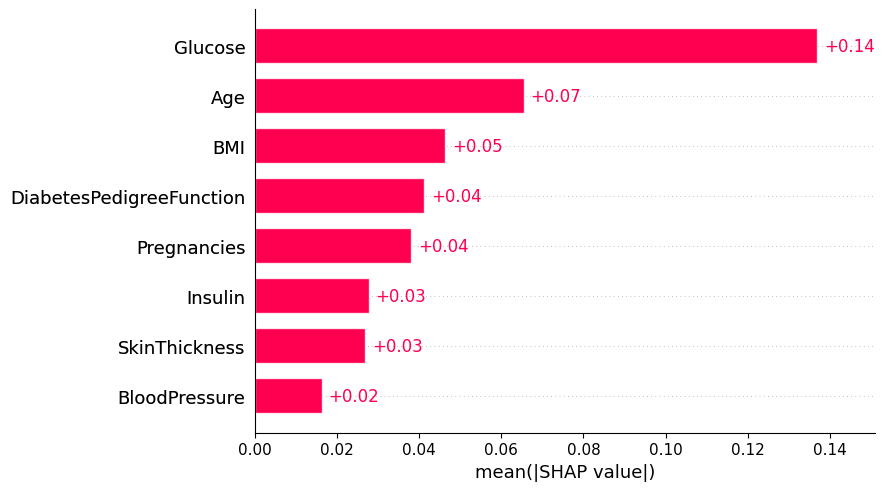

In [ ]:
shap.plots.bar(shap_values[:, :, 1])

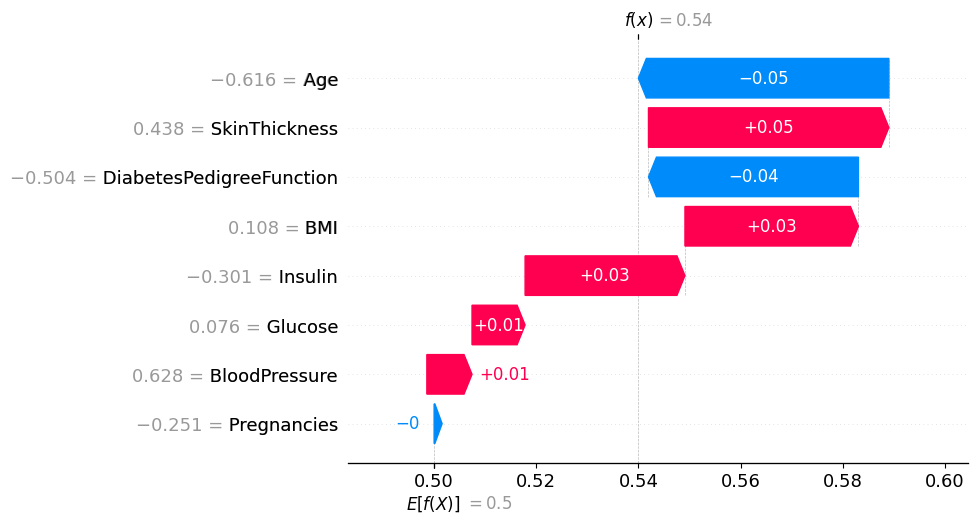

In [ ]:
shap.plots.waterfall(shap_values[0][:, 1])

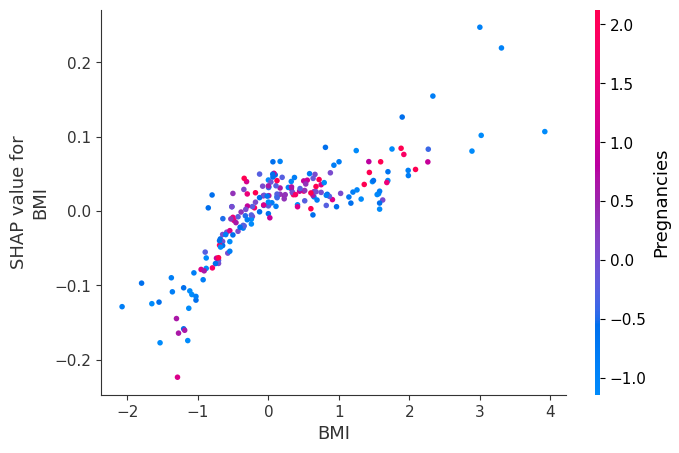

In [ ]:
shap.dependence_plot("BMI", shap_values[:, :, 1].values, X_test_df)

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0a259069d9c8317117f8daae8e334d8bc8821e859bf0cb2325c4a7906b2c221e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# Create explainer
lime_explainer = LimeTabularExplainer(
    X_train,
    feature_names=df.drop('Outcome', axis=1).columns,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification"
)

# Explain one instance
exp = lime_explainer.explain_instance(
    X_test[0],
    best_model.predict_proba
)

# Show explanation
exp.show_in_notebook()

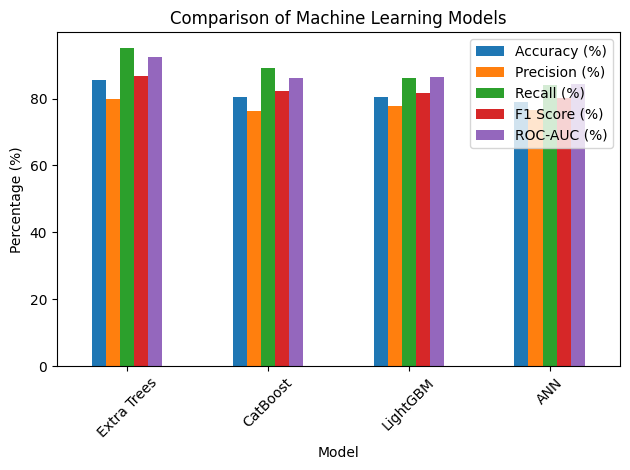

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1 Score (%)", "ROC-AUC (%)"]

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#E91E63']  # Green, Blue, Orange, Purple, Pink

df_results.set_index("Model")[metrics].plot(kind='bar', color=colors)

plt.title("Comparison of Machine Learning Models", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

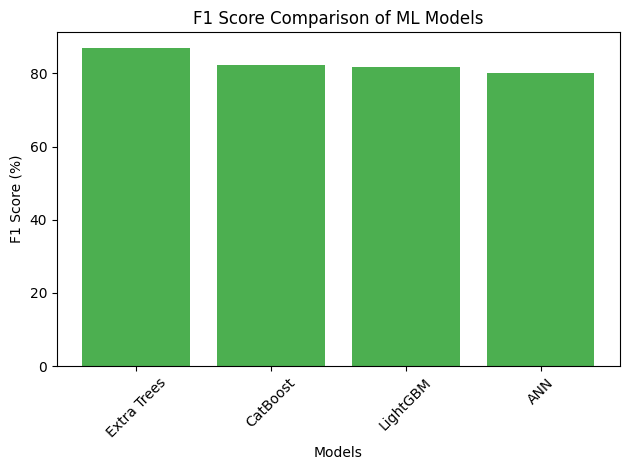

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["F1 Score (%)"], color='#4CAF50')
plt.title("F1 Score Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

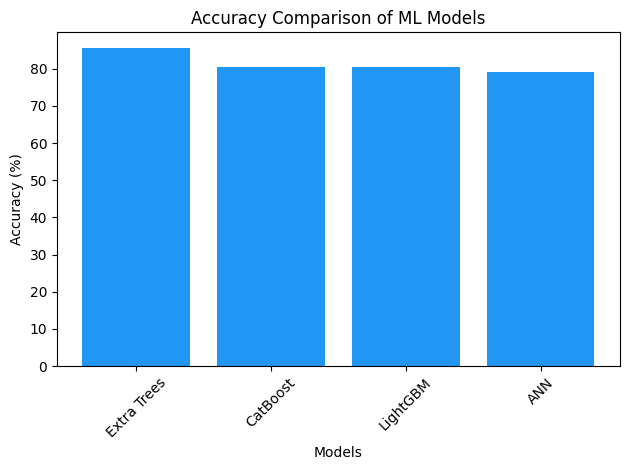

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["Accuracy (%)"], color='#2196F3')
plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

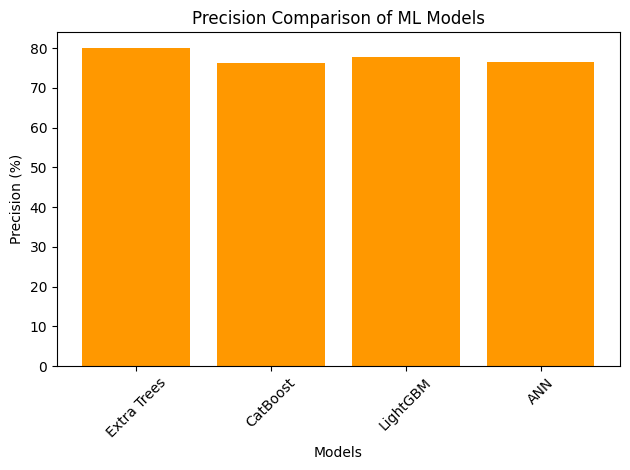

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["Precision (%)"], color='#FF9800')
plt.title("Precision Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Precision (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

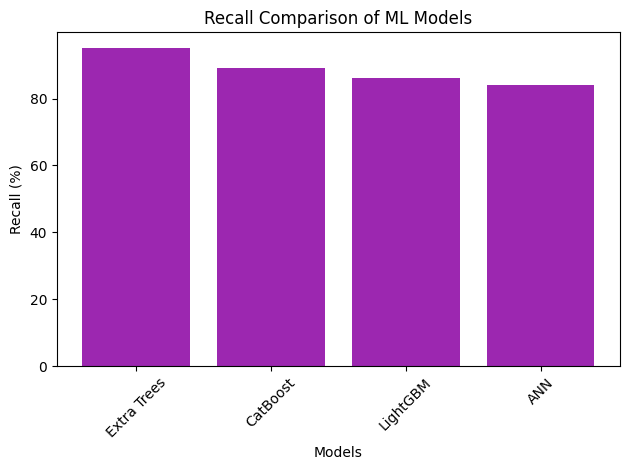

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["Recall (%)"], color='#9C27B0')
plt.title("Recall Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Recall (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

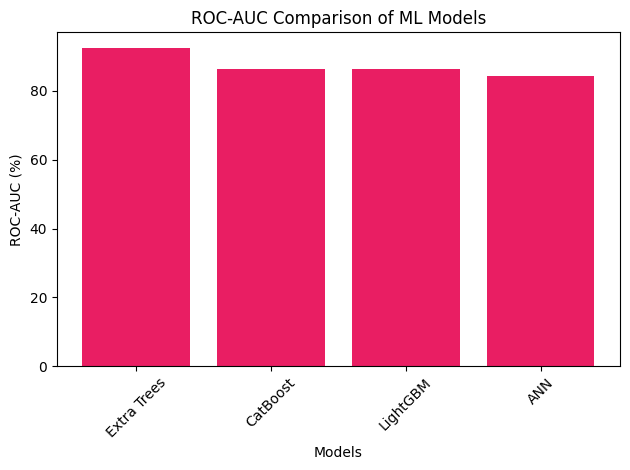

In [ ]:
plt.figure()
plt.bar(df_results["Model"], df_results["ROC-AUC (%)"], color='#E91E63')
plt.title("ROC-AUC Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("ROC-AUC (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


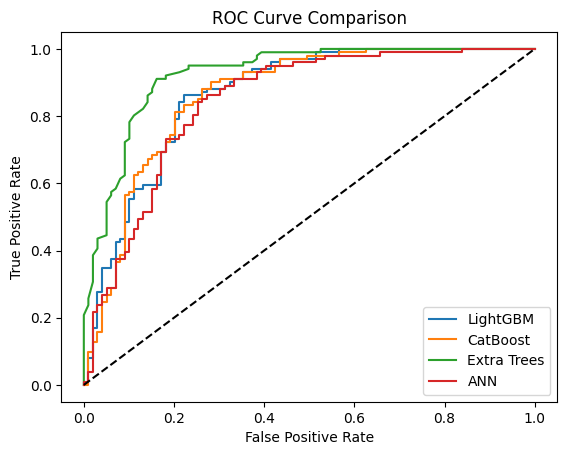

In [ ]:
from sklearn.metrics import roc_curve

plt.figure()

color_map = {
    "LightGBM": "#1f77b4",
    "CatBoost": "#ff7f0e",
    "Extra Trees": "#2ca02c",
    "ANN": "#d62728"
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name, color=color_map[name])

# ANN
y_prob_ann = ann.predict(X_test).flatten()
fpr, tpr, _ = roc_curve(y_test, y_prob_ann)
plt.plot(fpr, tpr, label="ANN", color=color_map["ANN"])

plt.plot([0,1], [0,1], linestyle='--', color='black')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()